# Motor Damage Segmentation — Full Pipeline

This is a faithful, reproducible record of the pipeline that actually built `cv/models/merged_v1_yolov8n_seg/best.pt` — not a simplified stand-in. Every cell here mirrors what was actually run (originally as standalone scripts over SSH on a GPU devserver, now consolidated here).

**Why it's shaped this way:**
1. Real Old Mutual claim photos don't exist yet, so we use two public Roboflow datasets as scaffolding: **CarDD** (2,000 images, already polygon-mask labeled) and **Skillfactory** (8,857 images, but only bounding-box labeled).
2. Skillfactory's boxes get converted to real polygon masks using **SAM** (Segment Anything), with an automatic quality check — if SAM's mask suspiciously fills almost its entire bounding box (a sign it grabbed the whole panel instead of the actual damage shape), we fall back to the plain box rather than propagate a wrong mask.
3. Both datasets get merged into **one unified 28-class taxonomy** that preserves Skillfactory's part-level detail (e.g. `bumper-dent-front` vs `bumper-dent-rear`) instead of collapsing everything into CarDD's coarser 11 classes.
4. Training happens in **two stages**: a baseline on CarDD alone, then the real model continues ("warm-starts") from that baseline's weights on the full merged dataset — the backbone's already-learned "what does car damage look like" features transfer, only the classification head resets for the new 28 classes.

**Hardware note:** SAM conversion and both training runs are heavy. This machine has no GPU (Intel Iris Xe only) — running the full notebook top-to-bottom here would take hours instead of the ~50 minutes it took on a GPU. Connect this notebook to a remote GPU kernel (Jupyter tunneled over SSH, or Colab) for the heavy cells; `DEVICE` below auto-detects and will use CPU with a much smaller effective batch if that's all you have, but the actual numbers reported throughout this notebook (mAP, timing) come from a GPU run.

**Idempotency:** the download, conversion, and merge cells skip work that's already done (checked via `.exists()`), so re-running this notebook after an interruption picks up where it left off rather than redoing everything.

## 0. Environment check

In [ ]:
import torch, ultralytics, cv2, sys

print("python:", sys.version)
print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available())
print("ultralytics:", ultralytics.__version__)
print("opencv:", cv2.__version__)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: no GPU detected. SAM conversion and training cells below will be very slow "
          "(the real run took ~80 min for SAM conversion + ~50 min for both training stages, on an RTX 3090).")

In [ ]:
from pathlib import Path
from dotenv import load_dotenv
import os

CV_ROOT = Path.cwd().parent  # cv/
load_dotenv(CV_ROOT / ".env")

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
assert ROBOFLOW_API_KEY, "Set ROBOFLOW_API_KEY in cv/.env first (copy cv/.env.example)."

DATA_DIR = CV_ROOT / "data"
MODELS_DIR = CV_ROOT / "models"
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

## 1. Download CarDD (polygon masks, 11 classes, 2,000 images)

In [ ]:
from roboflow import Roboflow

CARDD_DIR = DATA_DIR / "car-damage-severity-detection-cardd"

if (CARDD_DIR / "data.yaml").exists():
    print("Already downloaded, skipping:", CARDD_DIR)
    cardd_data_yaml = CARDD_DIR / "data.yaml"
else:
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("car-damage-detection-cardd").project("car-damage-severity-detection-cardd")
    dataset = project.version(3).download("yolov8", location=str(CARDD_DIR))
    cardd_data_yaml = Path(dataset.location) / "data.yaml"
    print("Downloaded to:", dataset.location)

## 2. EDA — sanity-check CarDD before spending compute on it

In [ ]:
import yaml

with open(cardd_data_yaml) as f:
    cardd_yaml = yaml.safe_load(f)

print("Classes:", cardd_yaml["names"])
print("Num classes:", cardd_yaml["nc"])

cardd_train_images = list((CARDD_DIR / "train" / "images").glob("*"))
cardd_val_images = list((CARDD_DIR / "valid" / "images").glob("*"))
print(f"Train images: {len(cardd_train_images)} | Val images: {len(cardd_val_images)}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def show_polygon_sample(img_path, ax, class_names):
    # Labels are YOLO *segmentation* polygons: "class x1 y1 x2 y2 ... xn yn" (normalized 0-1),
    # not fixed-width "class cx cy w h" boxes -- Roboflow's "object-detection" project label
    # on this dataset doesn't mean bbox-only export.
    label_path = Path(str(img_path).replace("images", "labels")).with_suffix(".txt")
    img = plt.imread(img_path)
    h, w = img.shape[:2]
    ax.imshow(img)
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            coords = list(map(float, parts[1:]))
            xs = [coords[i] * w for i in range(0, len(coords), 2)]
            ys = [coords[i] * h for i in range(1, len(coords), 2)]
            poly = patches.Polygon(list(zip(xs, ys)), closed=True, linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(poly)
            ax.text(min(xs), min(ys) - 5, class_names[cls], color="lime", fontsize=8)
    ax.axis("off")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flat, random.sample(cardd_train_images, min(6, len(cardd_train_images)))):
    show_polygon_sample(img_path, ax, cardd_yaml["names"])
plt.tight_layout()
plt.show()

## 3. Download Skillfactory (bounding boxes only, 31 classes, 8,857 images)

This is ~4x more images than CarDD, but only box-labeled — handled in the next section.

In [ ]:
SKILL_DIR = DATA_DIR / "skillfactory-car-damage"

if (SKILL_DIR / "data.yaml").exists():
    print("Already downloaded, skipping:", SKILL_DIR)
else:
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("skillfactory").project("car-damage-c1f0i")
    dataset = project.version(1).download("yolov8", location=str(SKILL_DIR))
    print("Downloaded to:", dataset.location)

with open(SKILL_DIR / "data.yaml") as f:
    skill_yaml = yaml.safe_load(f)
print("Skillfactory classes:", skill_yaml["nc"])

## 4. Convert Skillfactory boxes to real polygon masks (SAM + quality fallback)

A plain box-to-4-corner-rectangle conversion would work, but it isn't a real mask — it can't tell a thin scratch from a whole door panel. Instead we prompt **MobileSAM** with each box and let it segment the actual damage shape.

**Why the fallback matters**: SAM sometimes grabs the whole panel/surface instead of the specific damage (worst for thin, low-contrast damage like scratches). We measure `mask_area / box_area` per instance — if it's suspiciously close to 1.0 (SAM basically just filled the box), we use the plain box instead of a confidently wrong mask. This was verified empirically: **93.4% of the 10,092 damage instances got a real SAM polygon, 6.6% fell back to the box** — checked by hand against a visualized sample before trusting it for training.

MobileSAM (not full SAM2) was chosen specifically because the GPU here is shared with another team's Ollama LLM service, whose memory usage fluctuates unpredictably — MobileSAM's much smaller footprint (~40MB vs 150MB+) made it far more likely to actually fit when memory was tight.

In [ ]:
import numpy as np
from ultralytics import SAM

SKILL_SEG_DIR = DATA_DIR / "skillfactory-car-damage-seg"
FILL_RATIO_THRESHOLD = 0.92  # mask area / box area -- near-total fill means SAM likely grabbed
                              # the whole panel/surface, not the (usually irregular) damage shape


def mask_to_polygon(mask_bool):
    mask_u8 = mask_bool.astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 8:
        return None
    epsilon = 0.003 * cv2.arcLength(largest, True)
    approx = cv2.approxPolyDP(largest, epsilon, True)
    pts = approx.reshape(-1, 2)
    if len(pts) < 3:
        return None
    return pts, cv2.contourArea(largest)


def box_rectangle_polygon(x1, y1, x2, y2):
    return np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.float32)


def convert_split_to_polygons(sam_model, split, limit=0):
    img_dir = SKILL_DIR / split / "images"
    lbl_dir = SKILL_DIR / split / "labels"
    out_img_dir = SKILL_SEG_DIR / split / "images"
    out_lbl_dir = SKILL_SEG_DIR / split / "labels"
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    label_files = sorted(lbl_dir.glob("*.txt"))
    if limit:
        label_files = label_files[:limit]

    stats = {"images": 0, "boxes": 0, "masks": 0, "sam_polygons": 0, "box_fallbacks": 0}

    for i, label_path in enumerate(label_files):
        out_label_path = out_lbl_dir / label_path.name
        if out_label_path.exists():
            continue  # resume: already converted in a previous run

        img_candidates = list(img_dir.glob(label_path.stem + ".*"))
        if not img_candidates:
            continue
        img_path = img_candidates[0]
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        boxes, classes = [], []
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            cls, cx, cy, bw, bh = parts
            cx, cy, bw, bh = float(cx), float(cy), float(bw), float(bh)
            x1, y1 = max(0, (cx - bw / 2) * w), max(0, (cy - bh / 2) * h)
            x2, y2 = min(w, (cx + bw / 2) * w), min(h, (cy + bh / 2) * h)
            boxes.append([x1, y1, x2, y2])
            classes.append(int(cls))

        if not boxes:
            continue
        stats["images"] += 1
        stats["boxes"] += len(boxes)

        results = sam_model(str(img_path), bboxes=boxes, verbose=False, device=DEVICE)
        out_lines = []
        masks = results[0].masks
        if masks is not None:
            for cls, box, mask_tensor in zip(classes, boxes, masks.data):
                x1, y1, x2, y2 = box
                box_area = max(1.0, (x2 - x1) * (y2 - y1))
                mask_np = mask_tensor.cpu().numpy().astype(bool)
                result = mask_to_polygon(mask_np)
                if result is not None:
                    pts, mask_area = result
                    fill_ratio = mask_area / box_area
                else:
                    pts, fill_ratio = None, 1.0

                if pts is None or fill_ratio >= FILL_RATIO_THRESHOLD:
                    pts = box_rectangle_polygon(x1, y1, x2, y2)
                    stats["box_fallbacks"] += 1
                else:
                    stats["sam_polygons"] += 1

                norm_pts = []
                for x, y in pts:
                    norm_pts.append(round(float(x) / w, 6))
                    norm_pts.append(round(float(y) / h, 6))
                out_lines.append(str(cls) + " " + " ".join(str(v) for v in norm_pts))
                stats["masks"] += 1

        if out_lines:
            out_label_path.write_text("\n".join(out_lines))
            dst_img = out_img_dir / img_path.name
            if not dst_img.exists():
                os.symlink(img_path.resolve(), dst_img)

        if (i + 1) % 500 == 0:
            print(f"  [{split}] {i + 1}/{len(label_files)} done")

    return stats

In [ ]:
sam_model = SAM("mobile_sam.pt")  # auto-downloads once; ~40MB, small GPU footprint

total_stats = {"images": 0, "boxes": 0, "masks": 0, "sam_polygons": 0, "box_fallbacks": 0}
for split in ["train", "valid", "test"]:
    s = convert_split_to_polygons(sam_model, split)
    print(f"[{split}]", s)
    for k in total_stats:
        total_stats[k] += s[k]

print("\nTotal:", total_stats)
if total_stats["masks"]:
    print(f"Real SAM polygons: {100 * total_stats['sam_polygons'] / total_stats['masks']:.1f}%")

## 5. Verify SAM conversion quality before trusting it for training

Don't skip this — the first version of this conversion (without the fill-ratio fallback) produced masks that covered entire door panels and windshields instead of the actual scratch/dent. Always eyeball a sample before training on newly-generated labels.

In [ ]:
skill_seg_label_files = list((SKILL_SEG_DIR / "train" / "labels").glob("*.txt"))
sample = random.sample(skill_seg_label_files, min(9, len(skill_seg_label_files)))

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, lbl_path in zip(axes.flat, sample):
    img_path = list((SKILL_SEG_DIR / "train" / "images").glob(lbl_path.stem + ".*"))[0]
    show_polygon_sample(img_path, ax, skill_yaml["names"])
plt.tight_layout()
plt.show()

## 6. Merge into one unified 28-class taxonomy

CarDD's 11 classes are severity/generic-oriented (`glass-crack`, `lamp-crack`, `minor/moderate/severe-deformation`). Skillfactory's 31 classes are part-specific (`front-bumper-dent`, `rear-bumper-dent`, `damaged-windscreen`, ...). Collapsing everything down to CarDD's 11 would throw away real, useful part-level detail — knowing *which* part is damaged matters for verifying repair costs, which is a fraud signal. Instead we expand outward into a taxonomy that keeps Skillfactory's granularity and adds CarDD's severity/tire/paint concepts that Skillfactory lacks entirely.

**Two things worth knowing about this mapping:**
- A few Skillfactory labels were genuinely ambiguous (`damaged-rear-window` could mean the rear windscreen or a rear side window; `dent-or-scratch` is exactly what it says). Documented as `NOTE:` comments at each judgment call below.
- Skillfactory's generic `damaged` class (1,417 boxes with no specifics) was kept as its own `generic-damage` catch-all rather than dropped. Dropping it would force the model to either mislabel that visual pattern with false confidence, or miss it entirely at test time — both worse than an honest "something's damaged here, needs review" flag, which fits how this system is meant to work (human-in-the-loop, never auto-decides).

In [ ]:
MERGED_DIR = DATA_DIR / "merged-damage-dataset"

CARDD_CLASSES = [
    "car-part-crack", "detachment", "flat-tire", "glass-crack", "lamp-crack",
    "minor-deformation", "moderate-deformation", "paint-chips", "scratches",
    "severe-deformation", "side-mirror-crack",
]
SKILL_CLASSES = [
    "Front-Windscreen-Damage", "Headlight-Damage", "Major-Rear-Bumper-Dent",
    "Rear-windscreen-Damage", "RunningBoard-Dent", "Sidemirror-Damage",
    "Signlight-Damage", "Taillight-Damage", "bonnet-dent", "damaged",
    "damaged-door", "damaged-front-bumper", "damaged-head-light", "damaged-hood",
    "damaged-rear-bumper", "damaged-rear-window", "damaged-tail-light",
    "damaged-trunk", "damaged-window", "damaged-windscreen", "dent",
    "dent-or-scratch", "doorouter-dent", "fender-dent", "front-bumper-dent",
    "medium-Bodypanel-Dent", "pillar-dent", "quaterpanel-dent", "rear-bumper-dent",
    "roof-dent", "scratch",
]

# Final taxonomy -- order = final class index (must stay fixed once training starts).
UNIFIED_CLASSES = [
    "car-part-crack", "detachment", "flat-tire", "paint-chips", "minor-deformation",
    "moderate-deformation", "severe-deformation", "scratches", "side-mirror-crack",
    "glass-crack-generic", "lamp-damage-generic", "glass-crack-windscreen-front",
    "glass-crack-windscreen-rear", "glass-crack-window", "headlight-damage",
    "taillight-damage", "signlight-damage", "bumper-dent-front", "bumper-dent-rear",
    "hood-bonnet-dent", "door-dent", "fender-dent", "roof-dent", "pillar-dent",
    "runningboard-dent", "trunk-damage", "generic-dent", "generic-damage",
]
U = {name: i for i, name in enumerate(UNIFIED_CLASSES)}

CARDD_MAP = {
    "car-part-crack": U["car-part-crack"], "detachment": U["detachment"],
    "flat-tire": U["flat-tire"], "glass-crack": U["glass-crack-generic"],
    "lamp-crack": U["lamp-damage-generic"], "minor-deformation": U["minor-deformation"],
    "moderate-deformation": U["moderate-deformation"], "paint-chips": U["paint-chips"],
    "scratches": U["scratches"], "severe-deformation": U["severe-deformation"],
    "side-mirror-crack": U["side-mirror-crack"],
}

SKILL_MAP = {
    "Front-Windscreen-Damage": U["glass-crack-windscreen-front"],
    "Headlight-Damage": U["headlight-damage"],
    "Major-Rear-Bumper-Dent": U["bumper-dent-rear"],
    "Rear-windscreen-Damage": U["glass-crack-windscreen-rear"],
    "RunningBoard-Dent": U["runningboard-dent"],
    "Sidemirror-Damage": U["side-mirror-crack"],
    "Signlight-Damage": U["signlight-damage"],
    "Taillight-Damage": U["taillight-damage"],
    "bonnet-dent": U["hood-bonnet-dent"],
    "damaged": U["generic-damage"],
    "damaged-door": U["door-dent"],
    "damaged-front-bumper": U["bumper-dent-front"],
    "damaged-head-light": U["headlight-damage"],
    "damaged-hood": U["hood-bonnet-dent"],
    "damaged-rear-bumper": U["bumper-dent-rear"],
    # NOTE: assumption -- treated as a general window, not assumed to be the rear
    # windscreen (that's Rear-windscreen-Damage's job).
    "damaged-rear-window": U["glass-crack-window"],
    "damaged-tail-light": U["taillight-damage"],
    "damaged-trunk": U["trunk-damage"],
    "damaged-window": U["glass-crack-window"],
    # NOTE: assumption -- unqualified "windscreen" defaults to front.
    "damaged-windscreen": U["glass-crack-windscreen-front"],
    "dent": U["generic-dent"],
    # NOTE: assumption -- ambiguous "dent-or-scratch" bucketed with scratches.
    "dent-or-scratch": U["scratches"],
    "doorouter-dent": U["door-dent"],
    "fender-dent": U["fender-dent"],
    "front-bumper-dent": U["bumper-dent-front"],
    "medium-Bodypanel-Dent": U["generic-dent"],
    "pillar-dent": U["pillar-dent"],
    "quaterpanel-dent": U["fender-dent"],
    "rear-bumper-dent": U["bumper-dent-rear"],
    "roof-dent": U["roof-dent"],
    "scratch": U["scratches"],
}

CARDD_IDX_MAP = {i: CARDD_MAP[name] for i, name in enumerate(CARDD_CLASSES)}
SKILL_IDX_MAP = {i: SKILL_MAP[name] for i, name in enumerate(SKILL_CLASSES)}
print(f"Unified taxonomy: {len(UNIFIED_CLASSES)} classes")

In [ ]:
def remap_and_link(src_dir, idx_map, prefix, split):
    img_dir, lbl_dir = src_dir / split / "images", src_dir / split / "labels"
    out_img_dir = MERGED_DIR / split / "images"
    out_lbl_dir = MERGED_DIR / split / "labels"
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    n_images, n_instances = 0, 0
    for label_path in sorted(lbl_dir.glob("*.txt")):
        img_candidates = list(img_dir.glob(label_path.stem + ".*"))
        if not img_candidates:
            continue
        img_path = img_candidates[0]

        out_lines = []
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            old_cls = int(parts[0])
            if old_cls not in idx_map:
                continue
            out_lines.append(str(idx_map[old_cls]) + " " + " ".join(parts[1:]))
            n_instances += 1

        if not out_lines:
            continue
        new_name = f"{prefix}_{img_path.stem}"
        (out_lbl_dir / f"{new_name}.txt").write_text("\n".join(out_lines))
        dst_img = out_img_dir / f"{new_name}{img_path.suffix}"
        if not dst_img.exists():
            os.symlink(img_path.resolve(), dst_img)
        n_images += 1

    return n_images, n_instances


totals = {"images": 0, "instances": 0}
for split in ["train", "valid", "test"]:
    ci, cn = remap_and_link(CARDD_DIR, CARDD_IDX_MAP, "cardd", split)
    si, sn = remap_and_link(SKILL_SEG_DIR, SKILL_IDX_MAP, "skill", split)
    print(f"[{split}] CarDD: {ci} images / {cn} instances | Skillfactory: {si} images / {sn} instances")
    totals["images"] += ci + si
    totals["instances"] += cn + sn

merged_data_yaml_path = MERGED_DIR / "data.yaml"
merged_data_yaml_path.write_text(
    "names:\n" + "\n".join(f"- {c}" for c in UNIFIED_CLASSES) +
    f"\nnc: {len(UNIFIED_CLASSES)}\ntrain: ../train/images\nval: ../valid/images\ntest: ../test/images\n"
)
print(f"\nTotal merged: {totals['images']} images, {totals['instances']} instances, {len(UNIFIED_CLASSES)} classes")

## 7. Verify the merge — class names and masks should still make sense

In [ ]:
merged_label_files = list((MERGED_DIR / "train" / "labels").glob("*.txt"))
sample = random.sample(merged_label_files, min(9, len(merged_label_files)))

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, lbl_path in zip(axes.flat, sample):
    img_path = list((MERGED_DIR / "train" / "images").glob(lbl_path.stem + ".*"))[0]
    show_polygon_sample(img_path, ax, UNIFIED_CLASSES)
    ax.set_title(lbl_path.stem.split("_")[0], fontsize=8)  # "cardd" or "skill"
plt.tight_layout()
plt.show()

## 8. Stage 1 training — baseline on CarDD alone

This produces the checkpoint that Stage 2 warm-starts from. Real run: 60 epochs, imgsz=640, batch=32, GPU — finished in **~9 minutes**, box mAP50 **0.434**, mask mAP50 **0.429**.

If you're on CPU, drop `BATCH` and `EPOCHS` drastically (e.g. batch=4, epochs=5) or this will take hours.

In [ ]:
from ultralytics import YOLO
import time

EPOCHS = 60
IMGSZ = 640
BATCH = 32 if DEVICE == "cuda" else 4

baseline_run_name = "baseline_yolov8n_seg_damage"
baseline_ckpt = MODELS_DIR / "runs" / baseline_run_name / "weights" / "best.pt"

if baseline_ckpt.exists():
    print("Baseline already trained, skipping:", baseline_ckpt)
    baseline_model = YOLO(str(baseline_ckpt))
else:
    baseline_model = YOLO("yolov8n-seg.pt")  # COCO-pretrained nano segmentation checkpoint
    t0 = time.time()
    baseline_model.train(
        data=str(cardd_data_yaml), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, device=DEVICE,
        project=str(MODELS_DIR / "runs"), name=baseline_run_name, amp=True, workers=8,
    )
    print("TRAIN TIME:", time.time() - t0)

## 9. Stage 2 training — the real model, warm-started on the merged dataset

Loads Stage 1's weights instead of generic COCO weights, then trains on all 9,777 merged images across 28 classes. Ultralytics automatically transfers the backbone/neck (which already learned "what does car damage look like") and reinitializes just the classification head for the new class count.

Real run: 60 epochs, imgsz=640, batch=32, GPU — finished in **~37 minutes**, box mAP50 **0.536**, mask mAP50 **0.520**.

In [ ]:
merged_run_name = "merged_v1_yolov8n_seg"
merged_ckpt = MODELS_DIR / "runs" / merged_run_name / "weights" / "best.pt"

if merged_ckpt.exists():
    print("Merged model already trained, skipping:", merged_ckpt)
    final_model = YOLO(str(merged_ckpt))
else:
    final_model = YOLO(str(baseline_ckpt))  # warm start, not generic COCO weights
    t0 = time.time()
    final_model.train(
        data=str(merged_data_yaml_path), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, device=DEVICE,
        project=str(MODELS_DIR / "runs"), name=merged_run_name, amp=True, workers=8,
    )
    print("TRAIN TIME:", time.time() - t0)

## 10. Validate the final model

In [ ]:
metrics = final_model.val()
print("Box   mAP50:", metrics.box.map50, "| mAP50-95:", metrics.box.map)
print("Mask  mAP50:", metrics.seg.map50, "| mAP50-95:", metrics.seg.map)

## 11. Visualize predictions on held-out test images

**Test at more than one confidence threshold.** A single fixed threshold can make a real (but under-confident) detection look like a total miss — verified this directly: an image that showed "no detections" at conf=0.3 turned out to have correctly localized the damage at conf=0.05, just below the display cutoff.

In [ ]:
test_images = list((MERGED_DIR / "test" / "images").glob("*"))
sample_test = random.sample(test_images, min(6, len(test_images)))

pred_results = final_model.predict(source=[str(p) for p in sample_test], conf=0.3, device=DEVICE)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, r in zip(axes.flat, pred_results):
    ax.imshow(r.plot()[:, :, ::-1])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 12. Export to ONNX

Matches the plan's production-inference decision: lightweight ONNX runtime in `damage_cv_model.py`, no training stack needed in the FastAPI service. `damage_cv_model.py` (Module 3, not yet built) should read `.masks` from the output, not just `.boxes`, to get per-pixel damage area for the physics engine.

In [ ]:
onnx_path = final_model.export(format="onnx", imgsz=IMGSZ)
print("Exported:", onnx_path)

## 13. Test on your own photos

**This section is self-contained** — it doesn't need any cell above it to have run. Just restart the kernel (or open the notebook fresh), select the right kernel (see markdown at the very top), drop photos into `cv/data/my_test_photos/`, and run the one cell below.

Testing only on CarDD/Skillfactory images doesn't tell you how this will do on real Old Mutual claim photos — use photos from outside both training sets.

Loaded C:\Users\USER\Downloads\motor_insurance-master\motor_insurance-master\cv\models\merged_v1_yolov8n_seg\best.pt -- 28 classes, device=cpu

0: 640x640 (no detections), 509.3ms
1: 640x640 2 moderate-deformations, 1 door-dent, 509.3ms
2: 640x640 2 moderate-deformations, 1 scratches, 1 lamp-damage-generic, 509.3ms
3: 640x640 1 severe-deformation, 509.3ms
4: 640x640 2 car-part-cracks, 1 moderate-deformation, 1 lamp-damage-generic, 509.3ms
5: 640x640 (no detections), 509.3ms
Speed: 42.0ms preprocess, 509.3ms inference, 26.3ms postprocess per image at shape (1, 3, 640, 640)

images (1).jpg:
  No detections above conf threshold.

images (2).jpg:
  moderate-deformation: 0.704
  moderate-deformation: 0.493
  door-dent: 0.309

images (3).jpg:
  lamp-damage-generic: 0.869
  moderate-deformation: 0.821
  scratches: 0.819
  moderate-deformation: 0.607

images (4).jpg:
  severe-deformation: 0.275

images (5).jpg:
  car-part-crack: 0.770
  moderate-deformation: 0.760
  lamp-damage-generic: 0.758


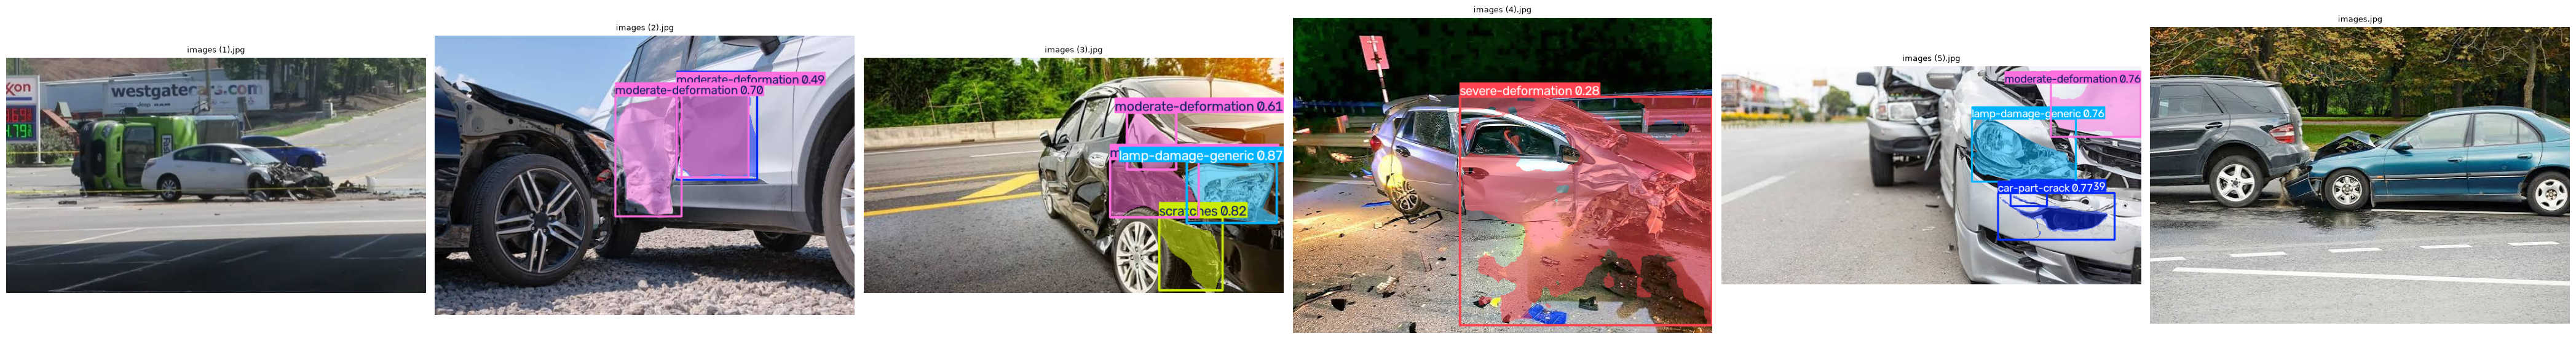

In [16]:
from pathlib import Path
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CV_ROOT = Path.cwd().parent  # cv/

# Two possible locations: a flat downloaded copy (cv/models/merged_v1_yolov8n_seg/best.pt),
# or the nested path Ultralytics produces if you trained it yourself in this notebook
# (cv/models/runs/merged_v1_yolov8n_seg/weights/best.pt). Use whichever exists.
CANDIDATE_MODEL_PATHS = [
    CV_ROOT / "models" / "merged_v1_yolov8n_seg" / "best.pt",
    CV_ROOT / "models" / "runs" / "merged_v1_yolov8n_seg" / "weights" / "best.pt",
]
MODEL_PATH = next((p for p in CANDIDATE_MODEL_PATHS if p.exists()), None)
assert MODEL_PATH is not None, (
    f"No trained checkpoint found in any of: {[str(p) for p in CANDIDATE_MODEL_PATHS]}. "
    "Run the training cells above first (sections 8-9), or copy merged_v1_yolov8n_seg/best.pt "
    "down from the server into cv/models/merged_v1_yolov8n_seg/."
)

TEST_PHOTOS_DIR = CV_ROOT / "data" / "my_test_photos"
TEST_PHOTOS_DIR.mkdir(parents=True, exist_ok=True)
CONF_THRESHOLD = 0.25  # lower this (e.g. 0.1) if you suspect real detections are being hidden

final_model = YOLO(str(MODEL_PATH))
print(f"Loaded {MODEL_PATH} -- {len(final_model.names)} classes, device={DEVICE}")

my_photos = [p for p in TEST_PHOTOS_DIR.glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")]
if not my_photos:
    print(f"No photos found in {TEST_PHOTOS_DIR} -- add some and re-run this cell.")
else:
    results = final_model.predict(source=[str(p) for p in my_photos], conf=CONF_THRESHOLD, device=DEVICE)

    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
    if n == 1:
        axes = [axes]

    for ax, r, photo in zip(axes, results, my_photos):
        ax.imshow(r.plot()[:, :, ::-1])
        ax.set_title(photo.name, fontsize=9)
        ax.axis("off")

        print(f"\n{photo.name}:")
        if r.boxes is None or len(r.boxes) == 0:
            print("  No detections above conf threshold.")
        else:
            for cls, conf in zip(r.boxes.cls, r.boxes.conf):
                print(f"  {final_model.names[int(cls)]}: {float(conf):.3f}")

    plt.tight_layout()
    plt.show()

## Known limitations (from actually testing this model)

- **Rare classes underperform**: `detachment` (10 training instances), `trunk-damage` (1 instance), `pillar-dent` (6 instances) all score mAP50 < 0.25 — a data volume problem, not a modeling failure. More examples of these specifically would help most.
- **Some over-triggering on texture**: a couple of test predictions covered almost an entire panel (e.g. `bumper-dent-rear` at 0.50 confidence spanning most of a bumper) — looks like the model sometimes reads dirt/texture as damage. Worth tightening with more negative (undamaged panel) examples.
- **`generic-damage` (mAP50 ~0.37) is intentionally imprecise** — it exists so ambiguous damage gets flagged for human review instead of forced into a wrong specific class or silently missed. Don't try to "fix" this class's precision without reconsidering whether it should exist at all.

## Next steps

1. Once real claim photos arrive: write `scripts/distill_gemini_labels.py` to weak-label them with the existing `_call_gemini_vision()` schema (Module 1), and fine-tune `final_model` (not from scratch) on that real domain data.
2. Add impact-zone (8-class) + ordinal crush-depth heads (ConvNeXt-Tiny), per Tier 1 in the plan — needs a labeled set with those fields, which Gemini distillation will produce.
3. Consider a second SAM pass with a larger model (e.g. `sam2_b.pt`) once GPU headroom is reliable, to see if it recovers some of the 6.6% that fell back to box masks.
4. Build `damage_cv_model.py` (Module 3) — the ONNX inference wrapper that the FastAPI service will actually call.